# EfficientNet-B0 Transfer Learning for Traffic Density and Incident Classification
This notebook fine-tunes a pretrained EfficientNet-B0 on the unified dataset (light, moderate, heavy, incident) using two-phase training: first training only the classifier head, then unfreezing the full network for end-to-end fine-tuning.

### 1. Imports and Setup

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import shutil
import seaborn as sns
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

# ── CLAHE custom transform ──────────────────────────────────────────────────
# Applied to PIL Images before ToTensor. Equalises local contrast per-channel
# to normalise lighting differences across the three source datasets.
class ApplyCLAHE:
    """Applies CLAHE (Contrast Limited Adaptive Histogram Equalisation) to a PIL image."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        # Convert PIL → numpy (BGR for OpenCV)
        img_np  = np.array(img)                          # H x W x 3, RGB uint8
        img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(img_lab)
        l_eq    = self.clahe.apply(l)                    # Equalise only the L channel
        img_lab_eq = cv2.merge((l_eq, a, b))
        img_rgb = cv2.cvtColor(img_lab_eq, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_rgb)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: mps


### 2. Dataset Loading and Augmentation
EfficientNet-B0 expects 224×224 inputs (its ImageNet training resolution). Three preprocessing additions are applied on top of the baseline pipeline:
- **CLAHE** (via `ApplyCLAHE`): normalises local contrast in LAB colour space to reduce lighting inconsistency across the Singapore, Traffic-Net, and Kathmandu sources.
- **ColorJitter**: simulates variable outdoor illumination.
- **RandomErasing**: randomly masks a rectangular patch after ToTensor, forcing the model to classify from overall scene density rather than a single salient region.

In [13]:
data_dir = 'merged_dataset'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),  # contrast normalisation
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3)),  # occlusion sim
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True,  num_workers=0),
    'val':   DataLoader(image_datasets['val'],   batch_size=32, shuffle=False, num_workers=0),
    'test':  DataLoader(image_datasets['test'],  batch_size=32, shuffle=False, num_workers=0),
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names   = image_datasets['train'].classes
num_classes   = len(class_names)

print('Classes:',      class_names)
print('Dataset sizes:', dataset_sizes)

Classes: ['heavy', 'incident', 'light', 'moderate']
Dataset sizes: {'train': 3567, 'val': 506, 'test': 534}


### 3. Offline Augmentation — Incident Class Balancing
The incident class has the smallest support across all three sources. Rather than relying solely on on-the-fly augmentation and loss weighting, we generate additional incident images offline by saving augmented copies to disk. This physically increases incident sample count before training begins.
**Run this cell once only.** It writes augmented images into `merged_dataset/train/incident/` and skips if they already exist.

In [14]:
import torchvision.transforms.functional as TF

INCIDENT_DIR    = os.path.join(data_dir, 'train', 'incident')
TARGET_MULTIPLE = 4   # generate this many augmented copies per original image
AUG_PREFIX      = 'aug_'  # prefix to identify generated files — avoids re-running

# Offline augmentation transforms (PIL-level, no normalisation)
offline_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15),
])

original_files = [
    f for f in os.listdir(INCIDENT_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith(AUG_PREFIX)
]

existing_aug = [f for f in os.listdir(INCIDENT_DIR) if f.startswith(AUG_PREFIX)]
print(f'Original incident images : {len(original_files)}')
print(f'Already augmented        : {len(existing_aug)}')

if existing_aug:
    print('Augmented files already exist — skipping. Delete aug_* files to regenerate.')
else:
    generated = 0
    for fname in original_files:
        img_path = os.path.join(INCIDENT_DIR, fname)
        img      = Image.open(img_path).convert('RGB')
        stem, ext = os.path.splitext(fname)

        for i in range(TARGET_MULTIPLE):
            aug_img  = offline_aug(img)
            out_name = f'{AUG_PREFIX}{stem}_v{i}{ext}'
            aug_img.save(os.path.join(INCIDENT_DIR, out_name))
            generated += 1

    print(f'Generated {generated} augmented incident images.')
    print(f'Incident class total: {len(original_files) + generated}')

Original incident images : 212
Already augmented        : 0
Generated 848 augmented incident images.
Incident class total: 1060


### 4. Handling Class Imbalance
The train dataset is reloaded from disk after offline augmentation so that the newly
generated incident images are included in the class count. Class weights are then
computed using inverse-frequency weighting and passed to CrossEntropyLoss.
This ensures the weight for the incident class reflects its true post-augmentation
count (~1,050) rather than the original 210 images.

In [15]:
# Reload train dataset after offline augmentation so augmented incident
# images are included in the class counts used for loss weighting.
image_datasets["train"] = datasets.ImageFolder(
    os.path.join(data_dir, "train"), data_transforms["train"]
)
dataloaders["train"] = DataLoader(
    image_datasets["train"], batch_size=32, shuffle=True, num_workers=0
)
dataset_sizes["train"] = len(image_datasets["train"])

train_classes = [label for _, label in image_datasets["train"].samples]
class_counts  = Counter(train_classes)
print("Class counts (post-augmentation):", class_counts)

total_samples = sum(class_counts.values())
class_weights = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:", dict(zip(class_names, [round(w, 4) for w in class_weights])))

Class counts (post-augmentation): Counter({2: 1935, 1: 1060, 0: 780, 3: 640})
Class weights: {'heavy': 1.4151, 'incident': 1.0413, 'light': 0.5704, 'moderate': 1.7246}


### 5. Model Setup — EfficientNet-B0 with Custom Classifier Head
We load EfficientNet-B0 pretrained on ImageNet and replace its final classifier layer with a new linear layer matching our 4-class output. All backbone weights are frozen initially — only the new head is trained in Phase 1.

In [16]:
# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all backbone parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head
# EfficientNet-B0 classifier: Sequential(Dropout(0.2), Linear(1280, 1000))
in_features = model.classifier[1].in_features  # 1280
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

# Verify — only classifier parameters should be trainable at this point
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable parameters: 5,124 / 4,012,672 (0.1%)


### 6. Training Loop
Reusable training function used for both Phase 1 (head only) and Phase 2 (full fine-tune).

In [17]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, phase_label=''):
    """
    Train model for num_epochs, tracking best val accuracy.
    Returns the model loaded with best weights and training history.
    """
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc       = 0.0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(num_epochs):
        print(f'{phase_label}Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss     = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.float() / dataset_sizes[phase]

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            print(f'  {phase.capitalize()} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc       = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    print(f'{phase_label}Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    history = {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc':  train_accs,   'val_acc':  val_accs
    }
    return model, history

### 7. Phase 1 — Train Classifier Head Only (10 Epochs)
With the backbone frozen, only the new classifier head is trained. A higher learning rate is used since these weights are randomly initialised. This warms up the head before the backbone is unfrozen.

In [18]:
criterion   = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Only pass classifier parameters to the optimiser (backbone is frozen)
optimizer_p1 = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=10)

print('--- Phase 1: Head Training ---')
model, history_p1 = train_model(
    model, criterion, optimizer_p1, scheduler_p1,
    num_epochs=10, phase_label='[Phase 1] '
)

--- Phase 1: Head Training ---
[Phase 1] Epoch 1/10
----------
  Train Loss: 0.6953  Acc: 0.7676
  Val Loss: 0.5591  Acc: 0.8043

[Phase 1] Epoch 2/10
----------
  Train Loss: 0.4916  Acc: 0.8236
  Val Loss: 0.4333  Acc: 0.8498

[Phase 1] Epoch 3/10
----------
  Train Loss: 0.4474  Acc: 0.8322
  Val Loss: 0.4220  Acc: 0.8379

[Phase 1] Epoch 4/10
----------
  Train Loss: 0.4192  Acc: 0.8390
  Val Loss: 0.4353  Acc: 0.8241

[Phase 1] Epoch 5/10
----------
  Train Loss: 0.4163  Acc: 0.8446
  Val Loss: 0.4011  Acc: 0.8557

[Phase 1] Epoch 6/10
----------
  Train Loss: 0.4077  Acc: 0.8507
  Val Loss: 0.3871  Acc: 0.8597

[Phase 1] Epoch 7/10
----------
  Train Loss: 0.4164  Acc: 0.8390
  Val Loss: 0.4036  Acc: 0.8399

[Phase 1] Epoch 8/10
----------
  Train Loss: 0.3908  Acc: 0.8487
  Val Loss: 0.3977  Acc: 0.8498

[Phase 1] Epoch 9/10
----------
  Train Loss: 0.3828  Acc: 0.8621
  Val Loss: 0.4004  Acc: 0.8518

[Phase 1] Epoch 10/10
----------
  Train Loss: 0.3810  Acc: 0.8523
  Val Loss:

### 8. Phase 2 — Full Fine-Tuning (15 Epochs)
The entire network is unfrozen and trained end-to-end at a much lower learning rate to avoid catastrophic forgetting of the pretrained ImageNet features.

In [19]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters (Phase 2): {trainable:,}')

# Low LR for backbone, slightly higher for classifier head
optimizer_p2 = optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 5e-4},
], weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_p2, T_0=5, T_mult=1)

print('--- Phase 2: Full Fine-Tuning ---')
model, history_p2 = train_model(
    model, criterion, optimizer_p2, scheduler_p2,
    num_epochs=15, phase_label='[Phase 2] '
)

# Save final weights
torch.save(model.state_dict(), 'efficientnet_b0_weights.pth')
print('Weights saved to efficientnet_b0_weights.pth')

Trainable parameters (Phase 2): 4,012,672
--- Phase 2: Full Fine-Tuning ---
[Phase 2] Epoch 1/15
----------
  Train Loss: 0.3682  Acc: 0.8623
  Val Loss: 0.3109  Acc: 0.8636

[Phase 2] Epoch 2/15
----------
  Train Loss: 0.2740  Acc: 0.8906
  Val Loss: 0.2559  Acc: 0.8874

[Phase 2] Epoch 3/15
----------
  Train Loss: 0.2321  Acc: 0.9087
  Val Loss: 0.2368  Acc: 0.8992

[Phase 2] Epoch 4/15
----------
  Train Loss: 0.1973  Acc: 0.9277
  Val Loss: 0.2476  Acc: 0.8933

[Phase 2] Epoch 5/15
----------
  Train Loss: 0.1864  Acc: 0.9228
  Val Loss: 0.2283  Acc: 0.9130

[Phase 2] Epoch 6/15
----------
  Train Loss: 0.1909  Acc: 0.9228
  Val Loss: 0.2186  Acc: 0.9032

[Phase 2] Epoch 7/15
----------
  Train Loss: 0.1801  Acc: 0.9300
  Val Loss: 0.2222  Acc: 0.9130

[Phase 2] Epoch 8/15
----------
  Train Loss: 0.1575  Acc: 0.9407
  Val Loss: 0.2523  Acc: 0.9051

[Phase 2] Epoch 9/15
----------
  Train Loss: 0.1328  Acc: 0.9477
  Val Loss: 0.2155  Acc: 0.9130

[Phase 2] Epoch 10/15
----------


### 9. Plotting Training Metrics
Plots are shown for each phase separately, then combined for a full training view.

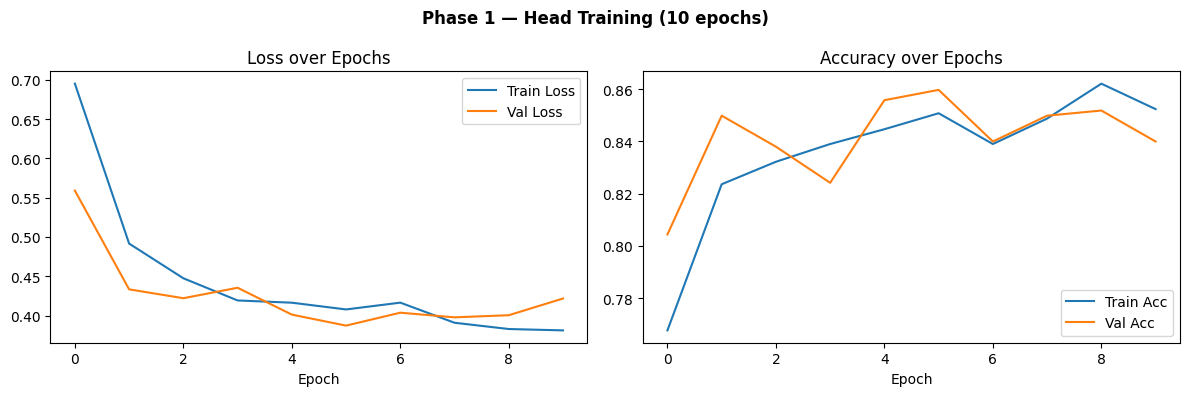

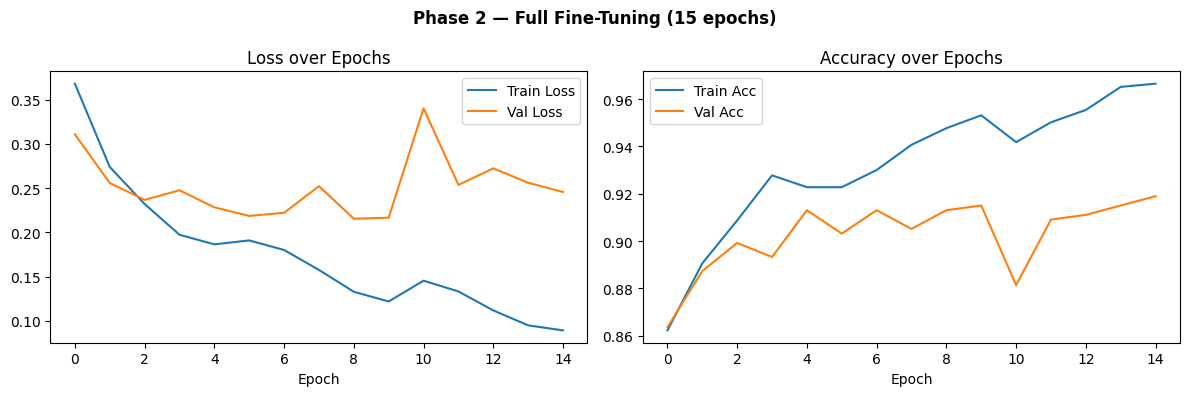

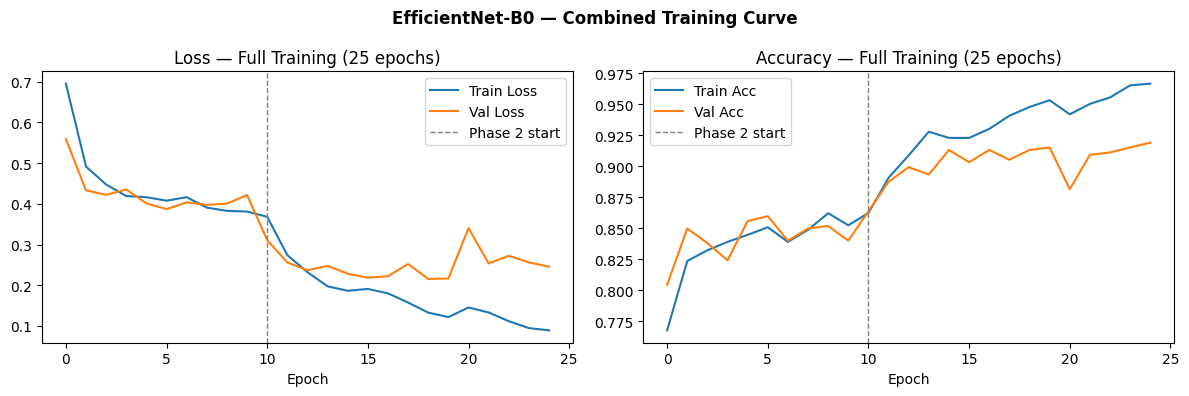

In [20]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'],   label='Val Loss')
    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'],   label='Val Acc')
    ax2.set_title('Accuracy over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    fig.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_p1, 'Phase 1 — Head Training (10 epochs)')
plot_history(history_p2, 'Phase 2 — Full Fine-Tuning (15 epochs)')

# Combined view across both phases
combined = {
    'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
    'val_loss':   history_p1['val_loss']   + history_p2['val_loss'],
    'train_acc':  history_p1['train_acc']  + history_p2['train_acc'],
    'val_acc':    history_p1['val_acc']    + history_p2['val_acc'],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(combined['train_loss'], label='Train Loss')
ax1.plot(combined['val_loss'],   label='Val Loss')
ax1.axvline(x=10, color='grey', linestyle='--', linewidth=1, label='Phase 2 start')
ax1.set_title('Loss — Full Training (25 epochs)')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(combined['train_acc'], label='Train Acc')
ax2.plot(combined['val_acc'],   label='Val Acc')
ax2.axvline(x=10, color='grey', linestyle='--', linewidth=1, label='Phase 2 start')
ax2.set_title('Accuracy — Full Training (25 epochs)')
ax2.set_xlabel('Epoch')
ax2.legend()

fig.suptitle('EfficientNet-B0 — Combined Training Curve', fontweight='bold')
plt.tight_layout()
plt.show()

### 10. Evaluate on Test Split

Classification Report:
              precision    recall  f1-score   support

       heavy       0.94      0.95      0.94       114
    incident       1.00      0.96      0.98        56
       light       0.97      0.95      0.96       271
    moderate       0.80      0.87      0.84        93

    accuracy                           0.94       534
   macro avg       0.93      0.93      0.93       534
weighted avg       0.94      0.94      0.94       534



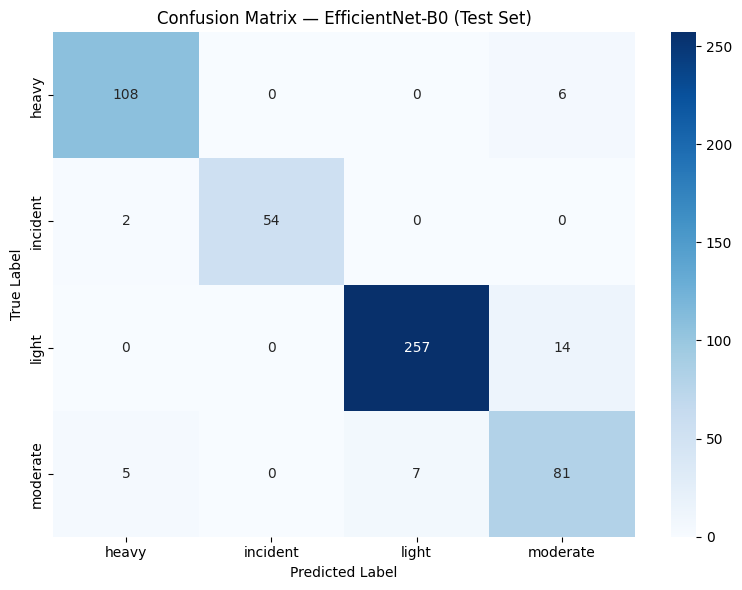

In [21]:
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — EfficientNet-B0 (Test Set)')
plt.tight_layout()
plt.show()

### 11. Single Image Inference

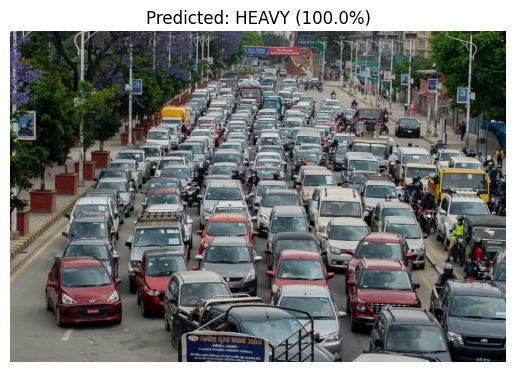

Class Probabilities:
  Heavy: 99.98%
  Incident: 0.00%
  Light: 0.01%
  Moderate: 0.01%


In [22]:
import torch.nn.functional as F
from PIL import Image

def predict_single_image(image_path):
    model.eval()

    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f'Error loading image: {e}')
        return

    input_tensor = data_transforms['val'](image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs       = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = torch.max(probabilities, 0)
        predicted_class = class_names[predicted_idx]

    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Predicted: {predicted_class.upper()} ({confidence.item()*100:.1f}%)')
    plt.show()

    print('Class Probabilities:')
    for i, cls_name in enumerate(class_names):
        print(f'  {cls_name.capitalize()}: {probabilities[i].item()*100:.2f}%')

# -- Usage --
# Replace with the path to any image you want to test
test_image_path = 'test.jpg'
predict_single_image(test_image_path)